=============================================================================
01 · Feature Engineering for RL Portfolio Optimizer

Builds per-stock feature panels consumed by the PPO-based RL environment.
Three separate agents (conservative, moderate, aggressive) receive filtered
stock universes from the volatility clustering model — this notebook produces
the feature panel for ALL stocks; filtering happens at environment init time.

Pipeline:
  1. Load all ticker CSVs, flag late-entry stocks
  2. Build outer-joined OHLCV panels, construct validity mask, forward-fill halts
  3. Compute 9 per-stock features + 1 market-wide regime signal
  4. Load LightGBM predicted returns and align to panel
  5. Split train/val/test, normalize using training stats only, export
  6. Sanity checks and visual diagnostics

Features (9 per stock per day):
  ret_1d              1-day log return (clamped ±25%)
  ret_5d              5-day cumulative log return
  ret_20d             20-day cumulative log return
  lgbm_pred           LightGBM predicted 21-day forward return
  gk_vol_20d          20-day Garman-Klass volatility
  skew_20d            20-day realized skewness
  kurt_20d            20-day realized kurtosis
  rel_volume          log(volume / 20d avg volume), lagged
  avg_pairwise_corr   avg Pearson correlation with all other stocks (20d)

Market-wide regime signal (saved separately as market_signal.pt):
  egx30_ma_ratio      MA(20) / MA(60) - 1 of equal-weight EGX30 proxy
                      > 0 = bullish trend, < 0 = bearish, 0 = neutral
                      Computed from equal-weight average of all 31 stock
                      close prices — no external data dependency.
                      Saved as float32 tensor of shape [T] and as a CSV
                      for inspection. Loaded separately by notebook 02.

Removed vs. prior GNN version:
  gk_vol_5d   — redundant given volatility clustering pre-filters stock universe
  sharpe_20d  — computable from retained features; removed to reduce redundancy

Temporal split (aligned with RL walk-forward evaluation):
  Train: 2015 → 2021-12-31
  Val:   2022-01-01 → 2022-12-31
  Test:  2023-01-01 → present

Output artifacts:
  Tensors (TENSORS_DIR):
    feature_tensor.pt     float32 [T, N, 9]
    market_signal.pt      float32 [T]          ← NEW: egx30_ma_ratio
    returns_tensor.pt     float32 [T, N]
    mask_tensor.pt        float32 [T, N]

  Metadata (METADATA_DIR):
    norm_stats.json       per-feature mean/std (training data only)
    market_signal_stats.json  mean/std for egx30_ma_ratio normalization ← NEW
    split_indices.json    train/val/test integer index ranges
    date_index.json       list of date strings
    feature_names.json    ordered list of 9 per-stock feature names
    meta.json             dataset metadata

  Features (FEATURES_DIR):
    feature_panel.csv     MultiIndex (date, ticker) human-readable panel
    egx30_proxy.csv       daily EGX30 proxy price and MA ratio            ← NEW
=============================================================================

In [1]:
# =============================================================================
# 1. Imports & Configuration
# =============================================================================
from pathlib import Path
import warnings
import json

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch

In [3]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [4]:
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})
PALETTE = {
    "primary":   "#2c7bb6",
    "secondary": "#d7191c",
    "tertiary":  "#fdae61",
    "accent":    "#abd9e9",
    "train":     "#2c7bb6",
    "val":       "#fdae61",
    "test":      "#2ca25f",
    "alert":     "#d7191c",
}

In [5]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("../../data/")
OHLCV_DIR     = DATA_DIR / "raw/OHLCV"
PANELS_DIR    = DATA_DIR / "processed/panels"
TENSORS_DIR   = DATA_DIR / "processed/tensors"
FEATURES_DIR  = DATA_DIR / "processed/features"
METADATA_DIR  = DATA_DIR / "processed/metadata"
PLOTS_DIR = Path("../../outputs/conservative/v3/plots")

for d in [PANELS_DIR, TENSORS_DIR, FEATURES_DIR, METADATA_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [6]:
# Path to LightGBM predicted returns CSV.
LGBM_PRED_PATH = Path("../../outputs/lgbm_forecasting/lgbm_predictions.csv")
DAILY_CLASSIFICATIONS_PATH = Path("../../outputs/volatility_clustering/daily_risk_classifications.csv")
MARKET_DATA_PATH = Path("../../data/conia_o_n_rate.xlsx")

In [7]:
# ── Feature parameters ────────────────────────────────────────────────────────
VOLUME_AVG_WINDOW = 20
RETURN_CLAMP      = 0.25
CORR_WINDOW       = 20

# ── Market regime signal parameters ───────────────────────────────────────────
MA_SHORT = 20   # short moving average window for EGX30 proxy
MA_LONG  = 60   # long moving average window for EGX30 proxy
# Ratio = MA_SHORT / MA_LONG - 1:
#   > 0  recent momentum above medium-term trend → bullish
#   < 0  recent momentum below medium-term trend → bearish
#   = 0  exactly neutral
# MA(20)/MA(60) chosen over MA(60)/MA(200) because our rebalancing is every
# 21 days — shorter windows capture actionable regime shifts faster.
CONIA_DELTA_WINDOW  = 60   # days over which to measure CONIA rate change

In [8]:
# ── Temporal split boundaries ─────────────────────────────────────────────────
TRAIN_END = "2021-12-31"
VAL_END   = "2022-12-31"

In [9]:
# ── Risk profile for this notebook run ────────────────────────────────────────
RISK_PROFILE = "conservative"   # conservative | balanced | aggressive

In [10]:
# ── Feature set (order = tensor dimension 2) ──────────────────────────────────
# NOTE: egx30_ma_ratio is NOT in this list — it is saved as a separate
# 1D tensor (market_signal.pt) because it is market-wide (same value for
# all stocks on a given day) and appended to obs in PortfolioEnv separately.
FEATURE_NAMES = [
    "ret_1d",
    "ret_5d",
    "ret_20d",
    "lgbm_pred",
    "gk_vol_20d",
    "skew_20d",
    "kurt_20d",
    "rel_volume",
    "avg_pairwise_corr",
]

In [11]:
# ── Load CSVs ─────────────────────────────────────────────────────────────────
if not OHLCV_DIR.exists():
    raise FileNotFoundError(f"OHLCV directory not found: {OHLCV_DIR.resolve()}")

csv_files = sorted(OHLCV_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files in {OHLCV_DIR.resolve()}\n")

Found 54 CSV files in C:\Users\youssef\Desktop\Portfolio_Personalization\data\raw\OHLCV



=============================================================================
2. Load & Inspect Raw Data
=============================================================================

In [12]:
def load_ticker(file_path: Path):
    """Load a single ticker CSV, standardize columns, return clean DataFrame."""
    ticker = file_path.stem.upper()
    df = pd.read_csv(file_path)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).copy()
    df = df.sort_values("datetime").drop_duplicates(subset=["datetime"], keep="last")
    df = df.set_index("datetime")
    for col in ["open", "high", "low", "close", "volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, ticker

In [13]:
raw_data    = {}
load_summary = []

for fp in csv_files:
    df, ticker = load_ticker(fp)
    raw_data[ticker] = df
    load_summary.append({
        "ticker":     ticker,
        "rows":       len(df),
        "start":      df.index.min(),
        "end":        df.index.max(),
        "null_close": int(df["close"].isna().sum()),
    })

summary_df = (
    pd.DataFrame(load_summary)
    .sort_values("start")
    .reset_index(drop=True)
)

print("Per-ticker data coverage (sorted by start date):\n")
print(summary_df[["ticker", "rows", "start", "end"]].to_string(index=False))

Per-ticker data coverage (sorted by start date):

ticker  rows               start                 end
  ORHD  3765 2007-06-21 10:00:00 2026-06-04 10:00:00
  BTFH  3522 2008-09-10 11:00:00 2026-06-04 10:00:00
  EAST  3765 2010-02-16 10:00:00 2026-06-04 10:00:00
  EGAL  3765 2010-05-10 10:00:00 2026-06-04 10:00:00
  MCQE  3765 2010-06-24 10:00:00 2026-06-04 10:00:00
  ABUK  3765 2010-07-07 10:00:00 2026-06-04 10:00:00
  GBCO  3765 2010-07-22 10:00:00 2026-06-04 10:00:00
  ORWE  3765 2010-09-02 11:00:00 2026-06-04 10:00:00
  JUFO  3765 2010-09-20 10:00:00 2026-06-04 10:00:00
  EGCH  3765 2010-09-21 10:00:00 2026-06-04 10:00:00
  ADIB  3765 2010-09-22 10:00:00 2026-06-04 10:00:00
  RAYA  3765 2010-09-26 10:00:00 2026-06-04 10:00:00
  HELI  3765 2010-09-26 10:00:00 2026-06-04 10:00:00
  VLMR  3765 2010-09-26 10:00:00 2026-06-04 10:00:00
  PHDC  3765 2010-09-27 10:00:00 2026-06-04 10:00:00
  HRHO  3765 2010-09-28 10:00:00 2026-06-04 10:00:00
  AMOC  3765 2010-09-29 10:00:00 2026-06-04 10:00

In [14]:
cutoff        = pd.Timestamp("2017-01-01")
late_tickers  = summary_df.loc[summary_df["start"] > cutoff, "ticker"].tolist()
early_tickers = summary_df.loc[summary_df["start"] <= cutoff, "ticker"].tolist()

print(f"\nFull-history tickers  : {len(early_tickers)}")
print(f"Late-entry tickers    : {len(late_tickers)}  (masked before their start date)")
for _, row in summary_df[summary_df["ticker"].isin(late_tickers)].iterrows():
    print(f"  {row['ticker']}: starts {row['start'].date()}")


Full-history tickers  : 26
Late-entry tickers    : 28  (masked before their start date)
  ISPH: starts 2017-12-11
  DSCW: starts 2018-01-22
  FAITA: starts 2018-01-22
  RMDA: starts 2019-11-27
  BINV: starts 2020-02-13
  EGTS: starts 2021-02-09
  MFPC: starts 2021-02-18
  SPMD: starts 2021-02-22
  EXPA: starts 2021-02-22
  CIRA: starts 2021-02-22
  OCDI: starts 2021-02-23
  SUGR: starts 2021-02-24
  PHAR: starts 2021-02-24
  SKPC: starts 2021-02-24
  FWRY: starts 2021-02-24
  MTIE: starts 2021-02-24
  HDBK: starts 2021-02-24
  FAIT: starts 2021-02-24
  CLHO: starts 2021-02-24
  CIEB: starts 2021-02-24
  CICH: starts 2021-02-24
  ASPI: starts 2021-02-24
  ARAB: starts 2021-02-24
  OFH: starts 2021-02-24
  TALM: starts 2021-03-24
  VLMRA: starts 2021-09-19
  GDWA: starts 2021-10-11
  EFIH: starts 2021-10-19


=============================================================================
3. Build Aligned OHLCV Panels & Validity Mask
=============================================================================

In [15]:
PRICE_COL = "close"

panel_columns = {"open": {}, "high": {}, "low": {}, "close": {}, "volume": {}}

for ticker, df in raw_data.items():
    valid = df[df[PRICE_COL].notna()].copy()
    for col in panel_columns:
        if col in valid.columns:
            panel_columns[col][ticker] = valid[col].rename(ticker)

panels_raw = {}
for col, series_dict in panel_columns.items():
    panel = pd.concat(series_dict.values(), axis=1, join="outer")
    panel.index = pd.to_datetime(panel.index).normalize()
    panel = panel[~panel.index.duplicated(keep="last")].sort_index()
    panels_raw[col] = panel

tickers = sorted(panels_raw["close"].columns.tolist())
for col in panels_raw:
    panels_raw[col] = panels_raw[col][tickers]

print(f"\nRaw outer-joined panels : {panels_raw['close'].shape}")
print(f"Date range              : {panels_raw['close'].index.min().date()} → "
      f"{panels_raw['close'].index.max().date()}")
print(f"Tickers                 : {len(tickers)}")


Raw outer-joined panels : (4517, 54)
Date range              : 2007-06-21 → 2026-06-04
Tickers                 : 54


In [16]:
validity_mask = panels_raw["close"].notna().astype(int)

stock_ranges = pd.DataFrame({
    "first_valid":         panels_raw["close"].apply(lambda c: c.first_valid_index()),
    "last_valid":          panels_raw["close"].apply(lambda c: c.last_valid_index()),
    "total_valid_days":    validity_mask.sum(),
    "total_calendar_days": len(panels_raw["close"]),
    "coverage_pct":        (validity_mask.sum() / len(panels_raw["close"]) * 100).round(1),
}).sort_values("first_valid")

print("\n── Stock Active Ranges ──")
print(stock_ranges.to_string())


── Stock Active Ranges ──
      first_valid last_valid  total_valid_days  total_calendar_days  coverage_pct
ORHD   2007-06-21 2026-06-04              3765                 4517          83.4
BTFH   2008-09-10 2026-06-04              3522                 4517          78.0
EAST   2010-02-16 2026-06-04              3765                 4517          83.4
EGAL   2010-05-10 2026-06-04              3765                 4517          83.4
MCQE   2010-06-24 2026-06-04              3765                 4517          83.4
ABUK   2010-07-07 2026-06-04              3765                 4517          83.4
GBCO   2010-07-22 2026-06-04              3765                 4517          83.4
ORWE   2010-09-02 2026-06-04              3765                 4517          83.4
JUFO   2010-09-20 2026-06-04              3765                 4517          83.4
EGCH   2010-09-21 2026-06-04              3765                 4517          83.4
ADIB   2010-09-22 2026-06-04              3765                 4517    

In [17]:
# Forward-fill within each stock's active range
panels_filled = {}
for col, panel in panels_raw.items():
    filled = panel.copy()
    for ticker in tickers:
        first  = stock_ranges.loc[ticker, "first_valid"]
        last   = stock_ranges.loc[ticker, "last_valid"]
        active = (filled.index >= first) & (filled.index <= last)
        if col == "volume":
            filled.loc[active, ticker] = filled.loc[active, ticker].ffill().fillna(0)
        else:
            filled.loc[active, ticker] = filled.loc[active, ticker].ffill()
    panels_filled[col] = filled

validity_mask_final = panels_filled["close"].notna().astype(int)

n_before = (validity_mask == 0).sum().sum()
n_after  = (validity_mask_final == 0).sum().sum()
print(f"\n── Fill Summary ──")
print(f"NaN cells before fill : {n_before}")
print(f"NaN cells after fill  : {n_after}  (filled {n_before - n_after} halt gaps)")

high_below_low = (
    (panels_filled["high"] < panels_filled["low"]) & panels_filled["close"].notna()
).sum().sum()
print(f"Days where High < Low : {high_below_low}  "
      f"{'✓ clean' if high_below_low == 0 else '⚠ investigate'}")


── Fill Summary ──
NaN cells before fill : 113074
NaN cells after fill  : 111089  (filled 1985 halt gaps)
Days where High < Low : 0  ✓ clean


In [18]:
# Save OHLCV panels
panels_filled["close"].to_csv(PANELS_DIR / "all_close_prices.csv")
panels_filled["open"].to_csv(PANELS_DIR / "all_open_prices.csv")
panels_filled["high"].to_csv(PANELS_DIR / "all_high_prices.csv")
panels_filled["low"].to_csv(PANELS_DIR / "all_low_prices.csv")
panels_filled["volume"].to_csv(PANELS_DIR / "all_volume.csv")
validity_mask_final.to_csv(PANELS_DIR / "validity_mask.csv")
stock_ranges.to_csv(PANELS_DIR / "stock_ranges.csv")

meta = {
    "tickers":        tickers,
    "late_tickers":   late_tickers,
    "n_stocks":       len(tickers),
    "date_start":     str(panels_filled["close"].index.min().date()),
    "date_end":       str(panels_filled["close"].index.max().date()),
    "n_trading_days": len(panels_filled["close"]),
}
with open(METADATA_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\nSaved OHLCV panels to {PANELS_DIR.resolve()}")


Saved OHLCV panels to C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\panels


=============================================================================
4. Feature Computation
=============================================================================

In [19]:
prices_df = panels_filled["close"]
open_df   = panels_filled["open"]
high_df   = panels_filled["high"]
low_df    = panels_filled["low"]
volume_df = panels_filled["volume"]

In [20]:
# 4a. Log returns with outlier clamp
log_returns_raw = np.log(prices_df / prices_df.shift(1))
n_pos = (log_returns_raw >  RETURN_CLAMP).sum().sum()
n_neg = (log_returns_raw < -RETURN_CLAMP).sum().sum()
log_returns = log_returns_raw.clip(lower=-RETURN_CLAMP, upper=RETURN_CLAMP)

print(f"\n── Return Clamping (±{RETURN_CLAMP}) ──")
print(f"Clamped {n_pos} positive and {n_neg} negative outliers "
      f"out of {log_returns_raw.notna().sum().sum():,} valid returns")

features = {}

# ret_1d: return from t-1 to t — known at t, no lag needed
features["ret_1d"]  = log_returns
features["ret_5d"]  = log_returns.rolling(5,  min_periods=5).sum().shift(1)
features["ret_20d"] = log_returns.rolling(20, min_periods=20).sum().shift(1)
print("✓ Returns: ret_1d, ret_5d, ret_20d")


── Return Clamping (±0.25) ──
Clamped 8 positive and 3 negative outliers out of 132,775 valid returns
✓ Returns: ret_1d, ret_5d, ret_20d


In [21]:
# 4b. Garman-Klass volatility
LOG2     = np.log(2)
log_hl   = np.log(high_df / low_df)
log_co   = np.log(prices_df / open_df)
gk_daily = 0.5 * log_hl**2 - (2 * LOG2 - 1) * log_co**2

features["gk_vol_20d"] = np.sqrt(
    gk_daily.rolling(20, min_periods=20).mean().shift(1).clip(lower=0)
)
print("✓ Garman-Klass volatility: gk_vol_20d")

✓ Garman-Klass volatility: gk_vol_20d


In [22]:
# 4c. Higher moments
features["skew_20d"] = log_returns.rolling(20, min_periods=20).skew().shift(1)
features["kurt_20d"] = log_returns.rolling(20, min_periods=20).kurt().shift(1)
print("✓ Higher moments: skew_20d, kurt_20d")

✓ Higher moments: skew_20d, kurt_20d


In [23]:
# 4d. Relative volume
vol_ma20              = volume_df.rolling(VOLUME_AVG_WINDOW, min_periods=VOLUME_AVG_WINDOW).mean().shift(1)
features["rel_volume"] = np.log1p(volume_df.shift(1) / (vol_ma20 + 1e-10))
print("✓ Relative volume: rel_volume")

✓ Relative volume: rel_volume


In [24]:
# 4e. Average pairwise correlation
print("Computing avg_pairwise_corr (this takes ~1-2 minutes)...")

dates_index = log_returns.index
corr_sum   = pd.DataFrame(0.0, index=dates_index, columns=tickers)
corr_count = pd.DataFrame(0,   index=dates_index, columns=tickers)

for i, t1 in enumerate(tickers):
    for j, t2 in enumerate(tickers):
        if i >= j:
            continue
        pair_corr = (
            log_returns[t1]
            .rolling(CORR_WINDOW, min_periods=CORR_WINDOW)
            .corr(log_returns[t2])
            .shift(1)
        )
        valid = pair_corr.notna()
        corr_sum.loc[valid, t1]   += pair_corr[valid]
        corr_sum.loc[valid, t2]   += pair_corr[valid]
        corr_count.loc[valid, t1] += 1
        corr_count.loc[valid, t2] += 1

features["avg_pairwise_corr"] = corr_sum / (corr_count + 1e-10)
features["avg_pairwise_corr"][corr_count == 0] = np.nan
print("✓ Average pairwise correlation: avg_pairwise_corr")

Computing avg_pairwise_corr (this takes ~1-2 minutes)...


✓ Average pairwise correlation: avg_pairwise_corr


In [25]:
# 4f. LightGBM predicted returns
if LGBM_PRED_PATH.exists():
    lgbm_raw = pd.read_csv(LGBM_PRED_PATH, index_col=0, parse_dates=True)
    lgbm_raw.index = pd.to_datetime(lgbm_raw.index).normalize()
    lgbm_raw = lgbm_raw[~lgbm_raw.index.duplicated(keep="last")].sort_index()
    lgbm_aligned = lgbm_raw.reindex(index=prices_df.index, columns=tickers)
    features["lgbm_pred"] = lgbm_aligned
    n_lgbm_valid = lgbm_aligned.notna().sum().sum()
    print(f"✓ LightGBM predictions loaded: {n_lgbm_valid:,} valid cells "
          f"({n_lgbm_valid / lgbm_aligned.size * 100:.1f}% coverage)")
else:
    print(f"⚠ LightGBM predictions not found at {LGBM_PRED_PATH}")
    print(f"  Creating NaN placeholder. Run forecasting notebook first.")
    features["lgbm_pred"] = pd.DataFrame(
        np.nan, index=prices_df.index, columns=tickers
    )

✓ LightGBM predictions loaded: 92,237 valid cells (37.8% coverage)


=============================================================================
4g. EGX30 Proxy Market Regime Signal

Computes MA(20)/MA(60) - 1 on an equal-weight average of all stock close
prices. This is the market-wide bull/bear signal appended to the RL agent's
observation vector in notebook 02.

Why equal-weight average of all 31 stocks?
  - No external data dependency — uses the close price panel already built
  - Consistent with the existing pipeline
  - All 31 stocks are EGX-listed so the average is a reasonable EGX proxy

Why MA(20)/MA(60)?
  - 20-day: captures recent momentum within the rebalancing cycle (21 days)
  - 60-day: ~3 months, medium-term trend reference
  - Ratio > 1 (normalized > 0): recent momentum above medium-term = bull
  - Ratio < 1 (normalized < 0): recent momentum below medium-term = bear
  - MA(60)/MA(200) would be too slow to react within 21-day rebalancing

Lagged by 1 day so the agent only sees information available at decision time.
Saved as a separate 1D tensor [T] — NOT inside feature_tensor because it is
the same value for all N stocks on a given day. Notebook 02 loads it and
appends it as one extra element to the observation vector.
=============================================================================

In [26]:
# Build EGX30 proxy: equal-weight mean of all available close prices per day
# Use only stocks that have valid data on each date (excludes NaN automatically)
egx30_proxy = prices_df.mean(axis=1)   # mean ignores NaN by default

print(f"\n── EGX30 Proxy ──")
print(f"First valid date : {egx30_proxy.first_valid_index().date()}")
print(f"Last valid date  : {egx30_proxy.last_valid_index().date()}")
print(f"NaN days         : {egx30_proxy.isna().sum()}")


── EGX30 Proxy ──
First valid date : 2007-06-21
Last valid date  : 2026-06-04
NaN days         : 0


In [27]:
# Confirm index is a proper DatetimeIndex, not integer timestamps
assert isinstance(prices_df.index, pd.DatetimeIndex), \
    "prices_df.index is not DatetimeIndex — normalize before computing EGX30 proxy"
print(f"prices_df.index dtype : {prices_df.index.dtype}")
print(f"First date            : {prices_df.index[0]}")
print(f"Last date             : {prices_df.index[-1]}")

prices_df.index dtype : datetime64[us]
First date            : 2007-06-21 00:00:00
Last date             : 2026-06-04 00:00:00


In [28]:
# Compute moving averages — no lag yet, applied to the proxy price series
egx30_ma_short = egx30_proxy.rolling(MA_SHORT, min_periods=MA_SHORT).mean()
egx30_ma_long  = egx30_proxy.rolling(MA_LONG,  min_periods=MA_LONG).mean()

# Ratio: MA(20) / MA(60) - 1
# Subtract 1 so the signal is centered at 0 (neutral)
egx30_ma_ratio_raw = (egx30_ma_short / egx30_ma_long) - 1.0

# Lag by 1 day: at time t, agent sees ratio computed up to t-1
egx30_ma_ratio = pd.Series(
    np.roll(egx30_ma_ratio_raw.values, 1),
    index=egx30_ma_ratio_raw.index
)
egx30_ma_ratio.iloc[0] = np.nan

print(f"\n── EGX30 MA Ratio (MA{MA_SHORT}/MA{MA_LONG} - 1) ──")
print(f"First valid date : {egx30_ma_ratio.first_valid_index().date()}")
print(f"NaN count        : {egx30_ma_ratio.isna().sum()} "
      f"(warmup: {MA_LONG} days + 1 lag = {MA_LONG + 1} days)")
print(f"Min              : {egx30_ma_ratio.min():.4f}")
print(f"Max              : {egx30_ma_ratio.max():.4f}")
print(f"Mean             : {egx30_ma_ratio.mean():.4f}")
print(f"Std              : {egx30_ma_ratio.std():.4f}")
print(f"% positive (bull): {(egx30_ma_ratio > 0).mean()*100:.1f}%")
print(f"% negative (bear): {(egx30_ma_ratio < 0).mean()*100:.1f}%")


── EGX30 MA Ratio (MA20/MA60 - 1) ──
First valid date : 2007-09-17
NaN count        : 60 (warmup: 60 days + 1 lag = 61 days)
Min              : -0.4806
Max              : 0.7379
Mean             : 0.0080
Std              : 0.0995
% positive (bull): 57.6%
% negative (bear): 41.0%


In [29]:
# Save the raw (unnormalized) proxy series for inspection
egx30_proxy_df = pd.DataFrame({
    "egx30_proxy":      egx30_proxy,
    "ma_short":         egx30_ma_short,
    "ma_long":          egx30_ma_long,
    "ma_ratio_raw":     egx30_ma_ratio_raw,
    "ma_ratio_lagged":  egx30_ma_ratio,
}, index=prices_df.index)

egx30_proxy_df.to_csv(FEATURES_DIR / "egx30_proxy.csv")
print(f"\nSaved EGX30 proxy series to {FEATURES_DIR / 'egx30_proxy.csv'}")


Saved EGX30 proxy series to ..\..\data\processed\features\egx30_proxy.csv


In [30]:
if MARKET_DATA_PATH.exists():
    # Read raw to find where headers actually are
    raw = pd.read_excel(MARKET_DATA_PATH, header=None)
    print("Raw first 5 rows:")
    print(raw.head(5).to_string())

    # Find the row containing 'Date' (case-insensitive, any column)
    header_row = None
    for i, row in raw.iterrows():
        if any("date" in str(v).lower() for v in row.values):
            header_row = i
            break

    if header_row is None:
        raise ValueError("Could not find a row containing 'Date' in the Excel file")

    print(f"\nHeader found at row index: {header_row}")

    conia_hist = pd.read_excel(MARKET_DATA_PATH, header=header_row)
    conia_hist.columns = [str(c).strip() for c in conia_hist.columns]
    print(f"Columns: {repr(conia_hist.columns.tolist())}")
    print(conia_hist.head(3).to_string())

    date_col = conia_hist.columns[0]
    rate_col = conia_hist.columns[1]
    print(f"Using date col: {repr(date_col)}  rate col: {repr(rate_col)}")

    conia_hist[date_col] = pd.to_datetime(conia_hist[date_col], dayfirst=True, errors="coerce")
    conia_hist = conia_hist.dropna(subset=[date_col])   # drops footnote rows and any empty rows
    conia_hist = conia_hist.sort_values(date_col).set_index(date_col)
    conia_hist.index = pd.to_datetime(conia_hist.index).normalize()
    conia_hist = conia_hist[~conia_hist.index.duplicated(keep="last")]

    conia_hist["conia_value"] = (
        pd.to_numeric(
            conia_hist[rate_col].astype(str).str.replace("%", "", regex=False).str.strip(),
            errors="coerce"
        ) / 100.0
    )

    conia_hist = conia_hist.dropna(subset=["conia_value"])

    print(f"CONIA history loaded   : {len(conia_hist)} rows")
    print(f"  Date range           : {conia_hist.index.min().date()} → {conia_hist.index.max().date()}")
    print(f"  Rate range           : [{conia_hist['conia_value'].min():.4f}, {conia_hist['conia_value'].max():.4f}]")

    macro_daily = (
        pd.DataFrame(index=prices_df.index)
        .merge(conia_hist[["conia_value"]], left_index=True, right_index=True, how="left")
        .ffill()
    )

    print(f"  Non-null after align : {macro_daily['conia_value'].notna().sum()} / {len(macro_daily)}")

    if "conia_value" in macro_daily.columns:
        conia_series = macro_daily["conia_value"]
        conia_delta  = conia_series.diff(CONIA_DELTA_WINDOW).shift(1)
        print(f"✓ conia_delta computed  "
              f"(range: [{conia_delta.min():.4f}, {conia_delta.max():.4f}])")
    else:
        print("⚠ conia_value not available — filling with 0")
        conia_delta = pd.Series(0.0, index=prices_df.index)

    print("⚠ inflation_delta — no historical CPI source yet, filling with 0")
    inflation_delta = pd.Series(0.0, index=prices_df.index)

else:
    print(f"⚠ CONIA data not found at {MARKET_DATA_PATH}")
    conia_delta     = pd.Series(0.0, index=prices_df.index)
    inflation_delta = pd.Series(0.0, index=prices_df.index)

print(f"\n── Macro Signal Coverage ──")
print(f"conia_delta valid     : {conia_delta.notna().sum()} / {len(conia_delta)}")
print(f"inflation_delta valid : {inflation_delta.notna().sum()} / {len(inflation_delta)}")

⚠ CONIA data not found at ..\..\data\conia_o_n_rate.xlsx

── Macro Signal Coverage ──
conia_delta valid     : 4517 / 4517
inflation_delta valid : 4517 / 4517


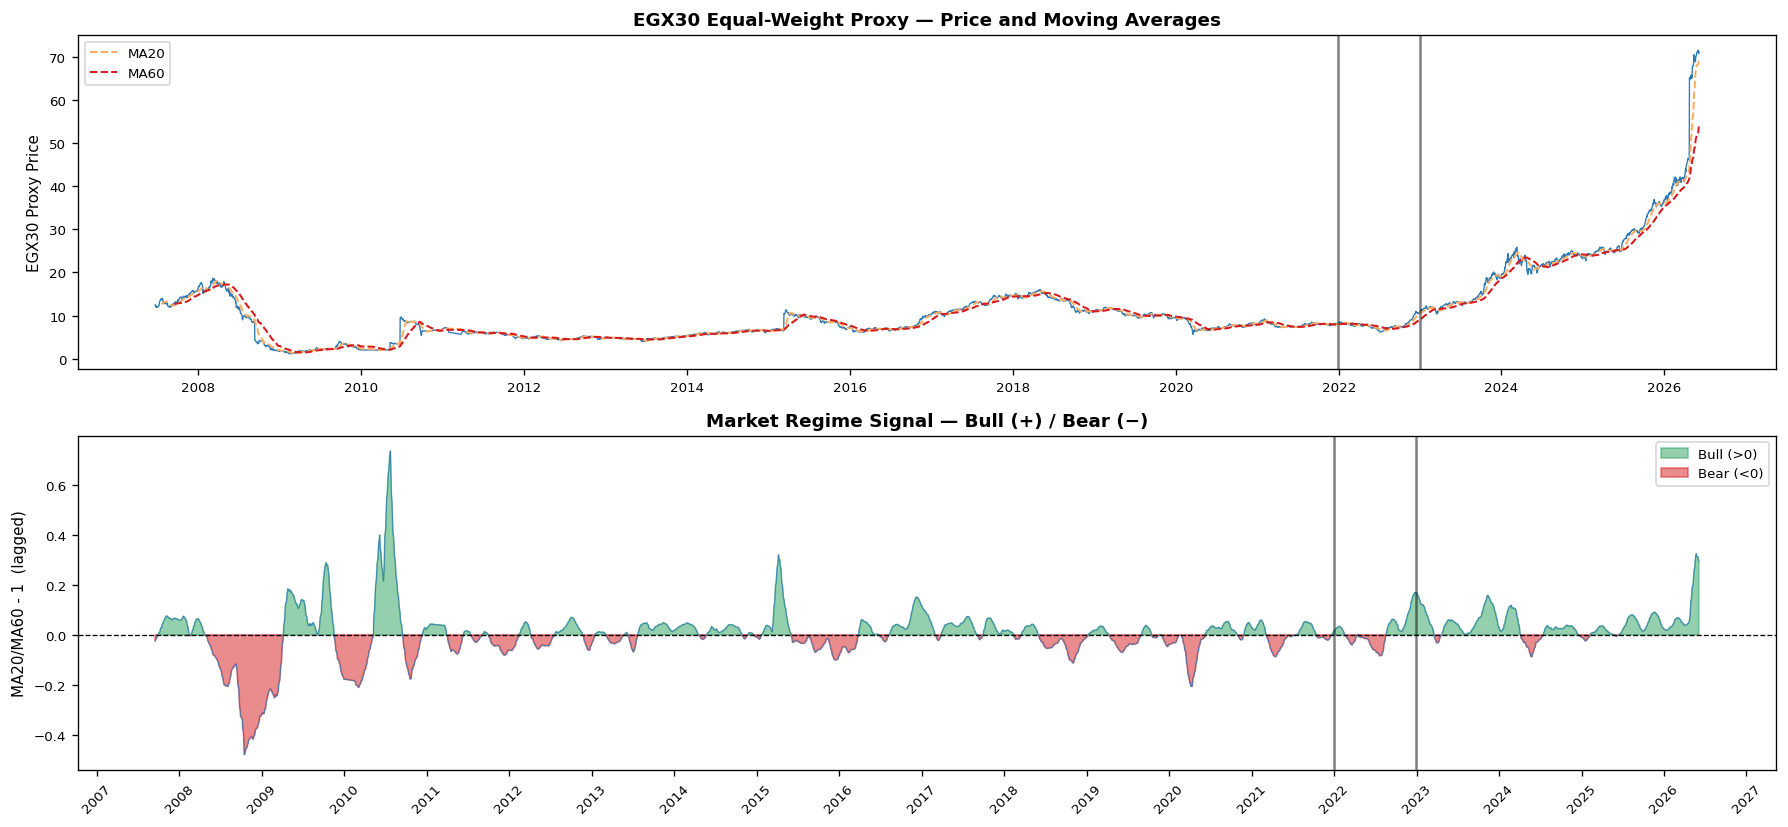

In [31]:
# Quick visual: proxy price + regime signal
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

ax = axes[0]
ax.plot(prices_df.index, egx30_proxy, color=PALETTE["primary"], linewidth=0.8)
ax.plot(prices_df.index, egx30_ma_short, color=PALETTE["tertiary"],
        linewidth=1.2, linestyle="--", label=f"MA{MA_SHORT}")
ax.plot(prices_df.index, egx30_ma_long, color=PALETTE["alert"],
        linewidth=1.2, linestyle="--", label=f"MA{MA_LONG}")
ax.set_ylabel("EGX30 Proxy Price")
ax.set_title("EGX30 Equal-Weight Proxy — Price and Moving Averages")
ax.legend(fontsize=8)
for b in [pd.Timestamp(TRAIN_END), pd.Timestamp(VAL_END)]:
    ax.axvline(b, color="black", linewidth=1.5, linestyle="-", alpha=0.5)

ax2 = axes[1]
bull_mask = egx30_ma_ratio > 0
bear_mask = egx30_ma_ratio < 0
ax2.fill_between(prices_df.index, egx30_ma_ratio,
                 where=bull_mask, color=PALETTE["test"],   alpha=0.5, label="Bull (>0)")
ax2.fill_between(prices_df.index, egx30_ma_ratio,
                 where=bear_mask, color=PALETTE["alert"],  alpha=0.5, label="Bear (<0)")
ax2.plot(prices_df.index, egx30_ma_ratio, color=PALETTE["primary"],
         linewidth=0.6, alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel(f"MA{MA_SHORT}/MA{MA_LONG} - 1  (lagged)")
ax2.set_title("Market Regime Signal — Bull (+) / Bear (−)")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
for b in [pd.Timestamp(TRAIN_END), pd.Timestamp(VAL_END)]:
    ax2.axvline(b, color="black", linewidth=1.5, linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "egx30_regime_signal.png", dpi=120, bbox_inches="tight")
plt.show()

=============================================================================
4h. Validate all per-stock feature shapes
=============================================================================

In [32]:
for name in FEATURE_NAMES:
    assert features[name].shape == prices_df.shape, \
        f"{name}: shape {features[name].shape} != prices shape {prices_df.shape}"
    assert (features[name].columns == prices_df.columns).all(), \
        f"{name}: column mismatch"

print(f"\n── Feature Coverage ({len(FEATURE_NAMES)} per-stock features) ──")
print(f"{'Feature':<22} {'Valid cells':>12} {'% of panel':>10}")
print("─" * 48)
for name in FEATURE_NAMES:
    n_valid = features[name].notna().sum().sum()
    pct = n_valid / features[name].size * 100
    print(f"{name:<22} {n_valid:>12,} {pct:>9.1f}%")


── Feature Coverage (9 per-stock features) ──
Feature                 Valid cells % of panel
────────────────────────────────────────────────
ret_1d                      132,775      54.4%
ret_5d                      132,529      54.3%
ret_20d                     131,719      54.0%
lgbm_pred                    92,237      37.8%
gk_vol_20d                  131,773      54.0%
skew_20d                    131,719      54.0%
kurt_20d                    131,719      54.0%
rel_volume                  131,773      54.0%
avg_pairwise_corr           129,325      53.0%


In [33]:
# =============================================================================
# 4i. Daily Risk Classifications (from volatility clustering RL)
# =============================================================================

# Load daily risk classifications produced by run_inference.py
# Shape after loading: [T, N] — 1 if stock matches RISK_PROFILE on that day, 0 otherwise
# NaN values (stocks with no classification) are treated as 0 (excluded)

if DAILY_CLASSIFICATIONS_PATH.exists():
    classifications_raw = pd.read_csv(
        DAILY_CLASSIFICATIONS_PATH, index_col=0, parse_dates=True
    )
    classifications_raw.index = pd.to_datetime(classifications_raw.index).normalize()
    classifications_raw = classifications_raw[
        ~classifications_raw.index.duplicated(keep="last")
    ].sort_index()

    # Reindex to full price panel date range and ticker list
    classifications_aligned = classifications_raw.reindex(
        index=prices_df.index, columns=tickers
    )

    # Build binary mask: 1 if classified as RISK_PROFILE, 0 otherwise (including NaN)
    profile_mask = (classifications_aligned == RISK_PROFILE).astype(float)
    # NaN → 0 (no classification = excluded from this profile's universe)
    profile_mask = profile_mask.fillna(0)

    n_profile_valid = profile_mask.sum().sum()
    print(f"\n── Daily Risk Classifications ──")
    print(f"Classification file : {DAILY_CLASSIFICATIONS_PATH}")
    print(f"Date range          : {classifications_aligned.index.min().date()} → "
          f"{classifications_aligned.index.max().date()}")
    print(f"Profile             : {RISK_PROFILE}")
    print(f"Valid stock-days    : {int(n_profile_valid):,} "
          f"({n_profile_valid / profile_mask.size * 100:.1f}% of panel)")

    # Show profile distribution on most recent date
    latest_date = classifications_aligned.index[classifications_aligned.notna().any(axis=1)][-1]
    latest_row  = classifications_aligned.loc[latest_date]
    print(f"Most recent date    : {latest_date.date()}")
    for profile in ("conservative", "balanced", "aggressive"):
        count = (latest_row == profile).sum()
        print(f"  {profile:<12} : {count} stocks")

else:
    print(f"⚠ Daily classifications not found at {DAILY_CLASSIFICATIONS_PATH}")
    print(f"  Run src/ingestion/run_inference.py first.")
    print(f"  Falling back to all stocks included in profile mask.")
    profile_mask = pd.DataFrame(1.0, index=prices_df.index, columns=tickers)


── Daily Risk Classifications ──
Classification file : ..\..\outputs\volatility_clustering\daily_risk_classifications.csv
Date range          : 2007-06-21 → 2026-06-04
Profile             : conservative
Valid stock-days    : 23,922 (9.8% of panel)
Most recent date    : 2026-03-31
  conservative : 10 stocks
  balanced     : 10 stocks
  aggressive   : 11 stocks


In [34]:
# Validate market signal shape
assert len(egx30_ma_ratio) == len(prices_df), \
    "egx30_ma_ratio length mismatch with prices panel"
print(f"\negx30_ma_ratio : {len(egx30_ma_ratio)} days  ✓")


egx30_ma_ratio : 4517 days  ✓


=============================================================================
5. Usable Date Range & Trim
=============================================================================

In [35]:
full_history_tickers = [t for t in tickers if t not in late_tickers]

# A date is usable when all per-stock features (except lgbm_pred) are valid
# for all full-history stocks AND the market regime signal is valid.
all_valid = pd.Series(True, index=prices_df.index)
for name in FEATURE_NAMES:
    if name == "lgbm_pred":
        continue
    all_valid = all_valid & features[name][full_history_tickers].notna().all(axis=1)

# Also require market signal to be valid
all_valid = all_valid & egx30_ma_ratio.notna()
# Macro signals use forward-fill so NaN only at the very start
# Only block dates where the primary egx30 signal is also unavailable
all_valid = all_valid & conia_delta.fillna(0).notna()
all_valid = all_valid & inflation_delta.fillna(0).notna()

first_usable_date = all_valid[all_valid].index.min()
print(f"\n── Usable Date Range ──")
print(f"First date all features valid : {first_usable_date.date()}")
print(f"Warmup days lost              : {prices_df.index.get_loc(first_usable_date)}")
print(f"  (MA{MA_LONG} + 1 lag = {MA_LONG+1} days dominates over {MA_SHORT}-day features)")


── Usable Date Range ──
First date all features valid : 2015-07-06
Warmup days lost              : 1870
  (MA60 + 1 lag = 61 days dominates over 20-day features)


In [36]:
# Trim everything to usable range
for name in FEATURE_NAMES:
    features[name] = features[name].loc[first_usable_date:]

egx30_ma_ratio_trimmed = egx30_ma_ratio.loc[first_usable_date:]

validity_mask_trimmed = validity_mask_final.loc[first_usable_date:]
prices_trimmed        = prices_df.loc[first_usable_date:]
log_returns_trimmed   = log_returns.loc[first_usable_date:]

conia_delta_trimmed = conia_delta.loc[first_usable_date:]
# Days before CONIA history starts have NaN — fill with 0 after normalization
# to represent "neutral / no information" rather than "rate unchanged"
# Track coverage for diagnostics
n_conia_missing = conia_delta_trimmed.isna().sum()
print(f"conia_delta NaN before fill : {n_conia_missing} days "
      f"({'pre-2016 gap + warmup' if n_conia_missing > 0 else 'none'})")
conia_delta_trimmed = conia_delta_trimmed.fillna(0)
inflation_delta_trimmed = inflation_delta.loc[first_usable_date:].fillna(0)

print(f"\nTrimmed panel : {prices_trimmed.shape[0]} days × {len(tickers)} stocks")
print(f"Date range    : {prices_trimmed.index.min().date()} → "
      f"{prices_trimmed.index.max().date()}")

# NaN check on egx30 after trim — should be zero
n_nan_signal = egx30_ma_ratio_trimmed.isna().sum()
print(f"Market signal NaN after trim : {n_nan_signal}  "
      f"{'✓' if n_nan_signal == 0 else '⚠ investigate'}")

conia_delta NaN before fill : 0 days (none)

Trimmed panel : 2647 days × 54 stocks
Date range    : 2015-07-06 → 2026-06-04
Market signal NaN after trim : 0  ✓


=============================================================================
6. Train / Validation / Test Split & Normalization
=============================================================================

In [37]:
TRAIN_END_TS = pd.Timestamp(TRAIN_END)
VAL_END_TS   = pd.Timestamp(VAL_END)

train_dates = prices_trimmed.index[prices_trimmed.index <= TRAIN_END_TS]
val_dates   = prices_trimmed.index[
    (prices_trimmed.index > TRAIN_END_TS) & (prices_trimmed.index <= VAL_END_TS)
]
test_dates  = prices_trimmed.index[prices_trimmed.index > VAL_END_TS]

print("\n── Temporal Split ──")
print(f"Train : {train_dates.min().date()} → {train_dates.max().date()} "
      f"({len(train_dates)} days, {len(train_dates)/len(prices_trimmed)*100:.1f}%)")
print(f"Val   : {val_dates.min().date()} → {val_dates.max().date()} "
      f"({len(val_dates)} days, {len(val_dates)/len(prices_trimmed)*100:.1f}%)")
print(f"Test  : {test_dates.min().date()} → {test_dates.max().date()} "
      f"({len(test_dates)} days, {len(test_dates)/len(prices_trimmed)*100:.1f}%)")

assert len(train_dates) + len(val_dates) + len(test_dates) == len(prices_trimmed)


── Temporal Split ──
Train : 2015-07-06 → 2021-12-30 (1579 days, 59.7%)
Val   : 2022-01-02 → 2022-12-29 (244 days, 9.2%)
Test  : 2023-01-02 → 2026-06-04 (824 days, 31.1%)


In [38]:
# 6a. Tighten validity mask: require ALL per-stock features to be non-NaN
feature_complete = pd.DataFrame(True, index=prices_trimmed.index, columns=tickers)
for name in FEATURE_NAMES:
    if name == "lgbm_pred":
        continue
    feature_complete = feature_complete & features[name][tickers].notna()

validity_mask_tight = (
    feature_complete & (validity_mask_trimmed == 1)
).astype(int)

diff = (validity_mask_trimmed.astype(int) - validity_mask_tight).sum()
print(f"\n── Mask Tightening ──")
print(f"Cells lost (price present but feature missing): {diff.sum()}")


── Mask Tightening ──
Cells lost (price present but feature missing): 588


In [39]:
# 6b. Normalization stats from training data only (per-stock features)
norm_stats = {}
for name in FEATURE_NAMES:
    train_vals = features[name].loc[train_dates].values.flatten()
    train_vals = train_vals[~np.isnan(train_vals)]
    mean = float(np.mean(train_vals))
    std  = float(np.std(train_vals))
    if std < 1e-8:
        print(f"  ⚠ {name}: std ≈ 0, setting std=1")
        std = 1.0
    norm_stats[name] = {"mean": mean, "std": std}

print("\n── Per-Stock Normalization Stats (training data only) ──")
print(f"{'Feature':<22} {'Mean':>12} {'Std':>12}")
print("─" * 48)
for name in FEATURE_NAMES:
    print(f"{name:<22} {norm_stats[name]['mean']:>12.6f} {norm_stats[name]['std']:>12.6f}")


── Per-Stock Normalization Stats (training data only) ──
Feature                        Mean          Std
────────────────────────────────────────────────
ret_1d                     0.000079     0.024031
ret_5d                     0.000269     0.062270
ret_20d                    0.000760     0.132452
lgbm_pred                  0.030143     0.003107
gk_vol_20d                 0.026771     0.010063
skew_20d                   0.070343     0.951021
kurt_20d                   1.284831     2.669027
rel_volume                 0.609476     0.416989
avg_pairwise_corr          0.251812     0.173793


In [40]:
# 6c. Normalization stats for market signal (training data only)
signal_train_vals = egx30_ma_ratio_trimmed.loc[train_dates].dropna().values
signal_mean = float(np.mean(signal_train_vals))
signal_std  = float(np.std(signal_train_vals))
if signal_std < 1e-8:
    signal_std = 1.0

market_signal_stats = {"mean": signal_mean, "std": signal_std}

# ── CONIA normalization — use only real data days, not zero-filled pre-history
conia_real_mask  = conia_delta.loc[first_usable_date:].notna()
conia_train_real = conia_delta.loc[first_usable_date:].loc[train_dates][
    conia_real_mask.loc[train_dates]
].values

if len(conia_train_real) > 0:
    conia_mean = float(np.mean(conia_train_real))
    conia_std  = float(np.std(conia_train_real))
else:
    conia_mean, conia_std = 0.0, 1.0
if conia_std < 1e-8: conia_std = 1.0

# Normalize — pre-history NaN days map to 0.0 (neutral) after fillna
conia_delta_normalized = (
    (conia_delta_trimmed - conia_mean) / conia_std
).fillna(0.0)

# ── Inflation normalization (zero-filled throughout, std forced to 1)
inflation_train = inflation_delta_trimmed.loc[train_dates].values
inflation_mean  = float(np.mean(inflation_train))
inflation_std   = float(np.std(inflation_train))
if inflation_std < 1e-8: inflation_std = 1.0

inflation_delta_normalized = (inflation_delta_trimmed - inflation_mean) / inflation_std

macro_signal_stats = {
    "conia_delta":     {"mean": conia_mean,     "std": conia_std},
    "inflation_delta": {"mean": inflation_mean, "std": inflation_std},
}

print(f"\n── Macro Signal Normalization Stats (training data only) ──")
print(f"  egx30_ma_ratio   mean={signal_mean:.6f}  std={signal_std:.6f}")
print(f"  conia_delta      mean={conia_mean:.6f}  std={conia_std:.6f}  "
      f"(from {len(conia_train_real)} real observations)")
print(f"  inflation_delta  mean={inflation_mean:.6f}  std={inflation_std:.6f}")


── Macro Signal Normalization Stats (training data only) ──
  egx30_ma_ratio   mean=-0.002507  std=0.050288
  conia_delta      mean=0.000000  std=1.000000  (from 1579 real observations)
  inflation_delta  mean=0.000000  std=1.000000


In [41]:
# 6d. Apply normalization to per-stock features
features_normalized = {}
for name in FEATURE_NAMES:
    features_normalized[name] = (
        (features[name] - norm_stats[name]["mean"]) / norm_stats[name]["std"]
    )

# 6e. Apply normalization to market signal
egx30_ma_ratio_normalized = (
    (egx30_ma_ratio_trimmed - signal_mean) / signal_std
)

In [42]:
# 6f. Verification
print("\n── Post-Normalization Verification (Per-Stock Features) ──")
print(f"{'Feature':<22} {'Tr μ':>8} {'Tr σ':>8} {'Va μ':>8} {'Va σ':>8} "
      f"{'Te μ':>8} {'Te σ':>8}")
print("─" * 76)
for name in FEATURE_NAMES:
    p = features_normalized[name]
    def stats(dates_slice):
        v = p.loc[dates_slice].values.flatten()
        v = v[~np.isnan(v)]
        return np.mean(v), np.std(v)
    tm, ts = stats(train_dates)
    vm, vs = stats(val_dates)
    em, es = stats(test_dates)
    print(f"{name:<22} {tm:>8.3f} {ts:>8.3f} {vm:>8.3f} {vs:>8.3f} "
          f"{em:>8.3f} {es:>8.3f}")

print(f"\n── Post-Normalization Verification (Market Signal) ──")
def signal_stats(dates_slice):
    v = egx30_ma_ratio_normalized.loc[dates_slice].dropna().values
    return np.mean(v), np.std(v)
tm, ts = signal_stats(train_dates)
vm, vs = signal_stats(val_dates)
em, es = signal_stats(test_dates)
print(f"{'egx30_ma_ratio':<22} {tm:>8.3f} {ts:>8.3f} {vm:>8.3f} {vs:>8.3f} "
      f"{em:>8.3f} {es:>8.3f}")


── Post-Normalization Verification (Per-Stock Features) ──


Feature                    Tr μ     Tr σ     Va μ     Va σ     Te μ     Te σ
────────────────────────────────────────────────────────────────────────────
ret_1d                    0.000    1.000    0.026    1.120    0.058    1.144


ret_5d                    0.000    1.000    0.051    0.976    0.115    1.004
ret_20d                   0.000    1.000    0.102    0.936    0.215    0.927
lgbm_pred                -0.000    1.000    0.019    0.885    0.088    1.269
gk_vol_20d               -0.000    1.000   -0.034    0.931   -0.044    1.169
skew_20d                  0.000    1.000    0.231    1.038    0.263    0.978
kurt_20d                  0.000    1.000    0.111    0.980    0.047    0.887
rel_volume                0.000    1.000    0.028    1.005    0.058    0.878
avg_pairwise_corr         0.000    1.000   -0.065    0.804   -0.155    0.916

── Post-Normalization Verification (Market Signal) ──
egx30_ma_ratio            0.000    1.000    0.306    1.157    0.924    1.130


=============================================================================
7. Build & Save Tensors
=============================================================================

In [43]:
T = len(prices_trimmed)
N = len(tickers)
F = len(FEATURE_NAMES)

# ── Per-stock feature tensor [T, N, F] ────────────────────────────────────────
feature_tensor = np.full((T, N, F), np.nan, dtype=np.float32)
for f_idx, name in enumerate(FEATURE_NAMES):
    feature_tensor[:, :, f_idx] = features_normalized[name][tickers].values

nan_count      = np.isnan(feature_tensor).sum()
feature_tensor = np.nan_to_num(feature_tensor, nan=0.0)

print(f"\n── Tensors ──")
print(f"Feature tensor shape : {feature_tensor.shape}  (T, N_stocks, N_features)")
print(f"NaN cells zeroed     : {nan_count:,} ({nan_count/feature_tensor.size*100:.1f}%)")

feature_tensor_pt = torch.from_numpy(feature_tensor)

# ── Returns tensor [T, N] ─────────────────────────────────────────────────────
returns_tensor    = log_returns_trimmed[tickers].values.astype(np.float32)
returns_tensor    = np.nan_to_num(returns_tensor, nan=0.0)
returns_tensor_pt = torch.from_numpy(returns_tensor)

# ── Mask tensor [T, N] ────────────────────────────────────────────────────────
mask_tensor    = validity_mask_tight[tickers].values.astype(np.float32)
mask_tensor_pt = torch.from_numpy(mask_tensor)

# ── Profile mask tensor [T, N] ────────────────────────────────────────────────
# 1 = stock is classified as RISK_PROFILE on this day, 0 = excluded
# Trimmed to match the usable date range
profile_mask_trimmed = profile_mask.loc[first_usable_date:]
profile_mask_tensor  = profile_mask_trimmed[tickers].values.astype(np.float32)
profile_mask_tensor_pt = torch.from_numpy(profile_mask_tensor)

print(f"Profile mask shape    : {profile_mask_tensor_pt.shape}  "
      f"(T, N_stocks) — 1=in profile, 0=excluded")
print(f"Profile mask coverage : {profile_mask_tensor.mean()*100:.1f}% "
      f"of stock-days in {RISK_PROFILE} profile")
# ── Market signal tensor [T, 2] ───────────────────────────────────────────────
# Column 0: egx30_ma_ratio  (price momentum regime)
# Column 1: conia_delta     (monetary policy regime — rising = tightening)
market_signal_stack = np.stack([
    np.nan_to_num(egx30_ma_ratio_normalized.values.astype(np.float32), nan=0.0),
    np.nan_to_num(conia_delta_normalized.values.astype(np.float32),     nan=0.0),
], axis=1)  # shape [T, 2]

market_signal_pt = torch.from_numpy(market_signal_stack)

print(f"Returns tensor shape  : {returns_tensor_pt.shape}")
print(f"Mask tensor shape     : {mask_tensor_pt.shape}")
print(f"Market signal shape   : {market_signal_pt.shape}  (T, 2 signals)")
print(f"  [0] egx30_ma_ratio  range: [{market_signal_stack[:,0].min():.3f}, {market_signal_stack[:,0].max():.3f}]")
print(f"  [1] conia_delta     range: [{market_signal_stack[:,1].min():.3f}, {market_signal_stack[:,1].max():.3f}]")
print(f"Mask coverage         : {mask_tensor.mean()*100:.1f}% valid")


── Tensors ──
Feature tensor shape : (2647, 54, 9)  (T, N_stocks, N_features)
NaN cells zeroed     : 366,090 (28.5%)


Profile mask shape    : torch.Size([2647, 54])  (T, N_stocks) — 1=in profile, 0=excluded


Profile mask coverage : 16.7% of stock-days in conservative profile
Returns tensor shape  : torch.Size([2647, 54])
Mask tensor shape     : torch.Size([2647, 54])
Market signal shape   : torch.Size([2647, 2])  (T, 2 signals)
  [0] egx30_ma_ratio  range: [-4.067, 6.523]
  [1] conia_delta     range: [0.000, 0.000]
Mask coverage         : 74.0% valid


In [44]:
# 7a. Build human-readable feature panel
panel_rows  = []
date_index  = prices_trimmed.index
for t_idx, date in enumerate(date_index):
    for n_idx, ticker in enumerate(tickers):
        if mask_tensor[t_idx, n_idx] == 0:
            continue
        row = {"date": date, "ticker": ticker}
        for f_idx, name in enumerate(FEATURE_NAMES):
            row[name] = float(feature_tensor[t_idx, n_idx, f_idx])
        panel_rows.append(row)

feature_panel_df = pd.DataFrame(panel_rows).set_index(["date", "ticker"])
feature_panel_df.to_csv(FEATURES_DIR / "feature_panel.csv")
print(f"\nFeature panel CSV    : {feature_panel_df.shape} (valid stock-days only)")


Feature panel CSV    : (105731, 9) (valid stock-days only)


In [45]:
# 7b. Split indices
all_dates  = prices_trimmed.index
date_to_idx = {d: i for i, d in enumerate(all_dates)}
split_indices = {
    "train": [date_to_idx[d] for d in train_dates],
    "val":   [date_to_idx[d] for d in val_dates],
    "test":  [date_to_idx[d] for d in test_dates],
}
print(f"\n── Split Indices ──")
print(f"Train : {split_indices['train'][0]} → {split_indices['train'][-1]} "
      f"({len(split_indices['train'])} days)")
print(f"Val   : {split_indices['val'][0]} → {split_indices['val'][-1]} "
      f"({len(split_indices['val'])} days)")
print(f"Test  : {split_indices['test'][0]} → {split_indices['test'][-1]} "
      f"({len(split_indices['test'])} days)")


── Split Indices ──
Train : 0 → 1578 (1579 days)
Val   : 1579 → 1822 (244 days)
Test  : 1823 → 2646 (824 days)


In [46]:
# 7c. Save all artifacts
torch.save(feature_tensor_pt, TENSORS_DIR / "feature_tensor.pt")
torch.save(returns_tensor_pt, TENSORS_DIR / "returns_tensor.pt")
torch.save(mask_tensor_pt,    TENSORS_DIR / "mask_tensor.pt")
torch.save(market_signal_pt,  TENSORS_DIR / "market_signal.pt")

with open(METADATA_DIR / "norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)

with open(METADATA_DIR / "market_signal_stats.json", "w") as f:
    json.dump(market_signal_stats, f, indent=2)

with open(METADATA_DIR / "macro_signal_stats.json", "w") as f:
    json.dump(macro_signal_stats, f, indent=2)

with open(METADATA_DIR / "split_indices.json", "w") as f:
    json.dump(split_indices, f, indent=2)

date_index_list = [str(d.date()) for d in all_dates]
with open(METADATA_DIR / "date_index.json", "w") as f:
    json.dump(date_index_list, f)

with open(METADATA_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURE_NAMES, f, indent=2)

# Add after saving mask_tensor_pt:
torch.save(profile_mask_tensor_pt, TENSORS_DIR / "profile_mask_tensor.pt")

meta.update({
    "train_end":           str(TRAIN_END_TS.date()),
    "val_end":             str(VAL_END_TS.date()),
    "n_train_days":        len(train_dates),
    "n_val_days":          len(val_dates),
    "n_test_days":         len(test_dates),
    "n_features":          F,
    "feature_names":       FEATURE_NAMES,
    "first_usable_date":   str(first_usable_date.date()),
    "market_signal": f"[egx30_ma_ratio MA{MA_SHORT}/MA{MA_LONG}-1, "
             f"conia_delta {CONIA_DELTA_WINDOW}d]",
    "market_signal_stats": market_signal_stats,
    "macro_signal_stats":  macro_signal_stats,
})
with open(METADATA_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ All artifacts saved:")
print(f"   Tensors  : {TENSORS_DIR.resolve()}")
print(f"   Metadata : {METADATA_DIR.resolve()}")
print(f"   Features : {FEATURES_DIR.resolve()}")


✅ All artifacts saved:
   Tensors  : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\tensors
   Metadata : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\metadata
   Features : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\features


=============================================================================
8. Sanity Checks & Diagnostics
=============================================================================

In [47]:
print("\n── 8a. Reload & Verify Saved Artifacts ──\n")

feat_check   = torch.load(TENSORS_DIR / "feature_tensor.pt", weights_only=False)
ret_check    = torch.load(TENSORS_DIR / "returns_tensor.pt", weights_only=False)
mask_check   = torch.load(TENSORS_DIR / "mask_tensor.pt",    weights_only=False)
signal_check = torch.load(TENSORS_DIR / "market_signal.pt",  weights_only=False)

with open(METADATA_DIR / "split_indices.json") as f:
    splits_check = json.load(f)
with open(METADATA_DIR / "norm_stats.json") as f:
    nstats_check = json.load(f)
with open(METADATA_DIR / "feature_names.json") as f:
    fnames_check = json.load(f)
with open(METADATA_DIR / "date_index.json") as f:
    dindex_check = json.load(f)
with open(METADATA_DIR / "meta.json") as f:
    meta_check = json.load(f)
with open(METADATA_DIR / "market_signal_stats.json") as f:
    signal_stats_check = json.load(f)

assert feat_check.shape  == feature_tensor_pt.shape
assert ret_check.shape   == returns_tensor_pt.shape
assert mask_check.shape  == mask_tensor_pt.shape
assert signal_check.shape[0] == feat_check.shape[0], \
    "Market signal length must match feature tensor T dimension"
assert signal_check.shape[1] == 2, \
    f"Expected market_signal shape [T, 2], got {signal_check.shape}"
assert torch.equal(feat_check,   feature_tensor_pt)
assert torch.equal(ret_check,    returns_tensor_pt)
assert torch.equal(mask_check,   mask_tensor_pt)
assert torch.equal(signal_check, market_signal_pt)
assert torch.isfinite(feat_check).all(),   "Feature tensor contains inf!"
assert torch.isfinite(ret_check).all(),    "Returns tensor contains inf!"
assert torch.isfinite(signal_check).all(), "Market signal contains inf!"

all_indices = sorted(splits_check["train"] + splits_check["val"] + splits_check["test"])
assert all_indices == list(range(T))
assert len(fnames_check) == feat_check.shape[2]
assert len(dindex_check) == feat_check.shape[0]

# Add after mask_check assertions:
profile_mask_check = torch.load(TENSORS_DIR / "profile_mask_tensor.pt", weights_only=False)
assert profile_mask_check.shape == mask_tensor_pt.shape, \
    f"Profile mask shape {profile_mask_check.shape} != mask tensor shape {mask_tensor_pt.shape}"
assert torch.isfinite(profile_mask_check).all(), "Profile mask contains inf/nan!"
print(f"Profile mask    : {profile_mask_check.shape}  "
      f"coverage={profile_mask_check.mean()*100:.1f}%  ✓")

print(f"Feature tensor  : {feat_check.shape}  dtype={feat_check.dtype}  ✓")
print(f"Returns tensor  : {ret_check.shape}  dtype={ret_check.dtype}  ✓")
print(f"Mask tensor     : {mask_check.shape}  dtype={mask_check.dtype}  ✓")
print(f"Market signal   : {signal_check.shape}  ✓")
print(f"  egx30 range   : [{signal_check[:,0].min():.3f}, {signal_check[:,0].max():.3f}]")
print(f"  conia range   : [{signal_check[:,1].min():.3f}, {signal_check[:,1].max():.3f}]")
print(f"Split coverage  : train={len(splits_check['train'])}, "
      f"val={len(splits_check['val'])}, test={len(splits_check['test'])}  ✓")
print(f"No infinities   : ✓")
print(f"No split gaps   : ✓")
print(f"\n✅ All saved artifacts verified.")


── 8a. Reload & Verify Saved Artifacts ──

Profile mask    : torch.Size([2647, 54])  coverage=16.7%  ✓
Feature tensor  : torch.Size([2647, 54, 9])  dtype=torch.float32  ✓
Returns tensor  : torch.Size([2647, 54])  dtype=torch.float32  ✓
Mask tensor     : torch.Size([2647, 54])  dtype=torch.float32  ✓
Market signal   : torch.Size([2647, 2])  ✓
  egx30 range   : [-4.067, 6.523]
  conia range   : [0.000, 0.000]
Split coverage  : train=1579, val=244, test=824  ✓
No infinities   : ✓
No split gaps   : ✓

✅ All saved artifacts verified.


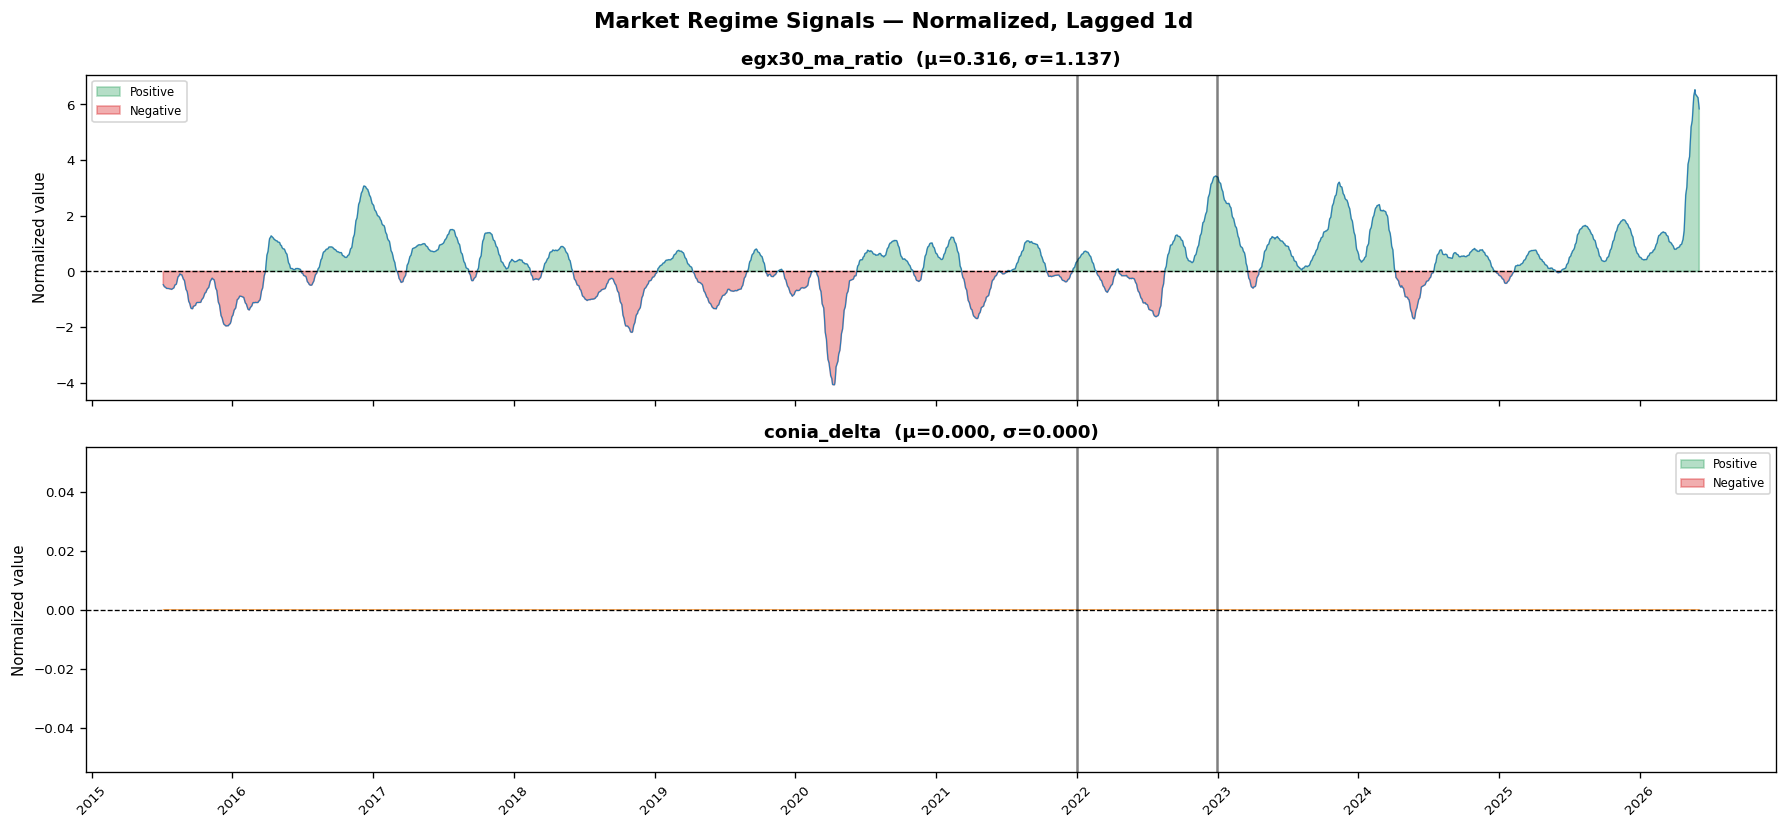

In [48]:
# ── 8b. Market signal over time with regime annotation ────────────────────────
dates_pd    = pd.to_datetime(dindex_check, format="%Y-%m-%d")
signal_vals = signal_check.numpy()   # shape [T, 2]

assert pd.to_datetime(dindex_check[0]).year >= 2015, \
    f"Date index starts at unexpected year: {dindex_check[0]}"

signal_names  = ["egx30_ma_ratio", "conia_delta"]
signal_colors = [PALETTE["primary"], PALETTE["tertiary"]]
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
for i, (name, color) in enumerate(zip(signal_names, signal_colors)):
    ax  = axes[i]
    sv  = signal_vals[:, i]
    ax.plot(dates_pd, sv, color=color, linewidth=0.7)
    ax.fill_between(dates_pd, sv, where=sv > 0,
                    color=PALETTE["test"],  alpha=0.35, label="Positive")
    ax.fill_between(dates_pd, sv, where=sv < 0,
                    color=PALETTE["alert"], alpha=0.35, label="Negative")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Normalized value")
    ax.set_title(f"{name}  (μ={sv.mean():.3f}, σ={sv.std():.3f})")
    ax.legend(fontsize=7)
    for b, lbl in [(TRAIN_END_TS, "Train→Val"), (VAL_END_TS, "Val→Test")]:
        ax.axvline(b, color="black", linewidth=1.5, linestyle="-", alpha=0.5)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.suptitle("Market Regime Signals — Normalized, Lagged 1d", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "market_signals_normalized.png", dpi=120, bbox_inches="tight")
plt.show()

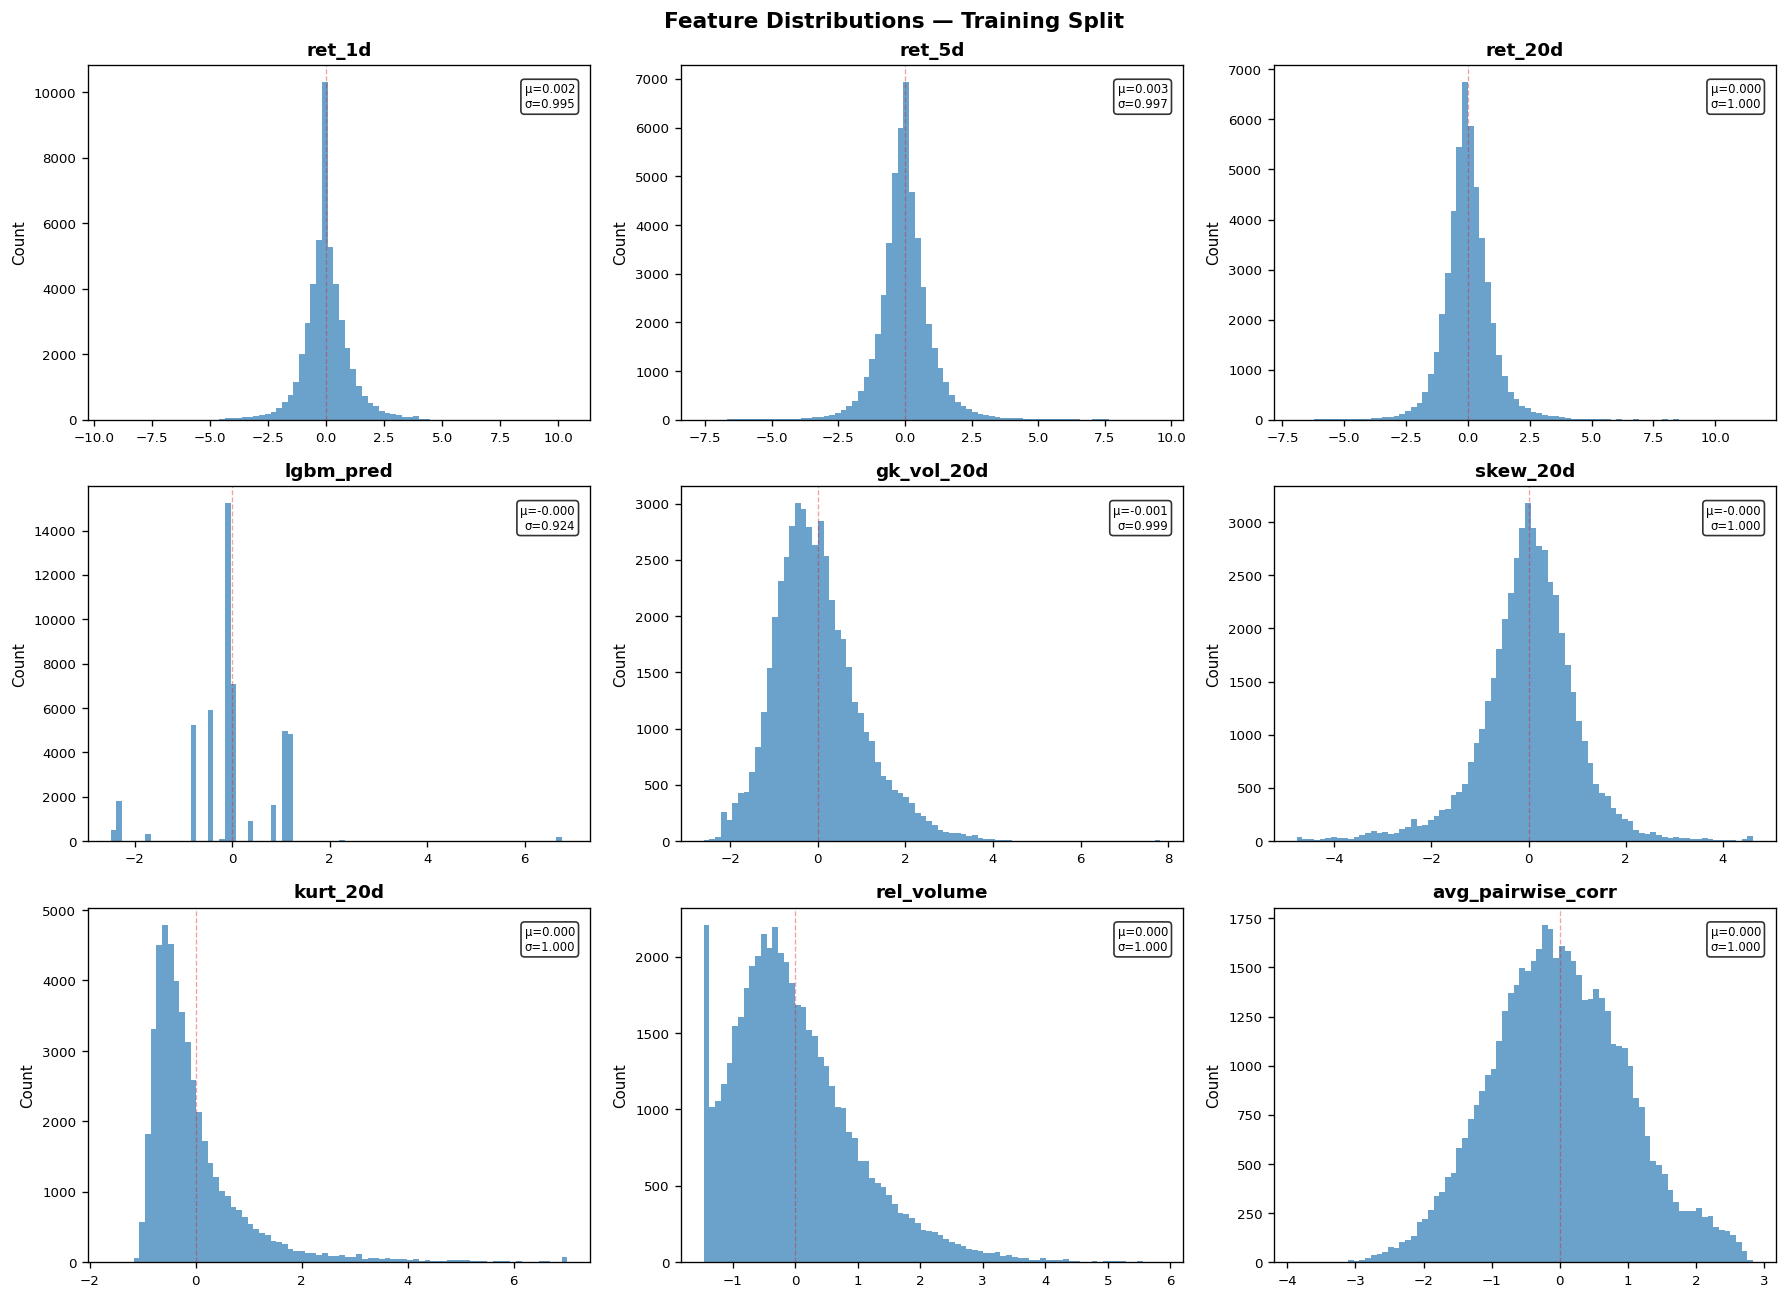

In [49]:
# ── 8c. Feature distributions ────────────────────────────────────────────────
train_feat = feat_check[splits_check["train"][0]:splits_check["train"][-1]+1]
train_mask = mask_check[splits_check["train"][0]:splits_check["train"][-1]+1]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    vals = train_feat[:, :, i][train_mask.bool()].numpy()
    ax.hist(vals, bins=80, color=PALETTE["primary"], alpha=0.7, edgecolor="none")
    ax.axvline(0, color=PALETTE["alert"], linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_title(name)
    ax.set_ylabel("Count")
    mu, sigma = vals.mean(), vals.std()
    ax.text(0.97, 0.95, f"μ={mu:.3f}\nσ={sigma:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
fig.suptitle("Feature Distributions — Training Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diag_feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

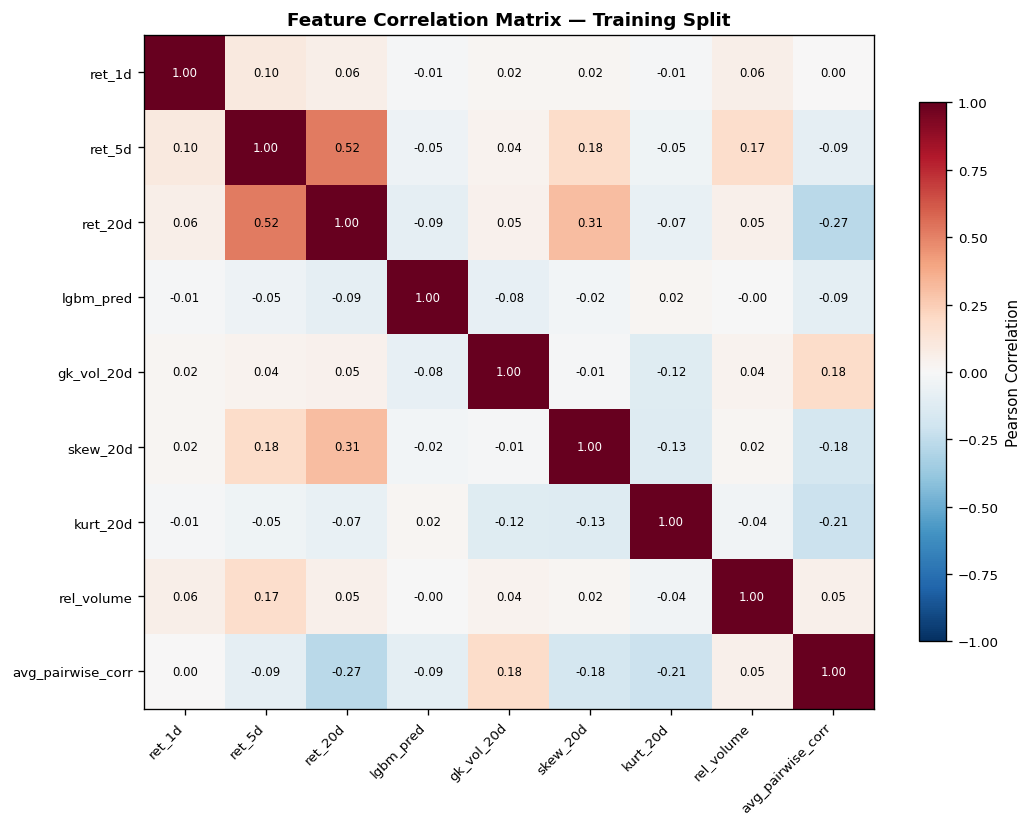


── High Correlations (|r| > 0.7) ──
  None above threshold


In [50]:
# ── 8d. Feature correlation matrix ───────────────────────────────────────────
train_flat  = train_feat.reshape(-1, F)
valid_flat  = train_flat[train_mask.reshape(-1).bool()].numpy()
corr_matrix = np.corrcoef(valid_flat.T)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(F))
ax.set_yticks(range(F))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
for i in range(F):
    for j in range(F):
        val   = corr_matrix[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson Correlation")
ax.set_title("Feature Correlation Matrix — Training Split")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diag_feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n── High Correlations (|r| > 0.7) ──")
found = False
for i in range(F):
    for j in range(i+1, F):
        if abs(corr_matrix[i, j]) > 0.7:
            print(f"  {FEATURE_NAMES[i]} ↔ {FEATURE_NAMES[j]}: {corr_matrix[i, j]:.3f}")
            found = True
if not found:
    print("  None above threshold")

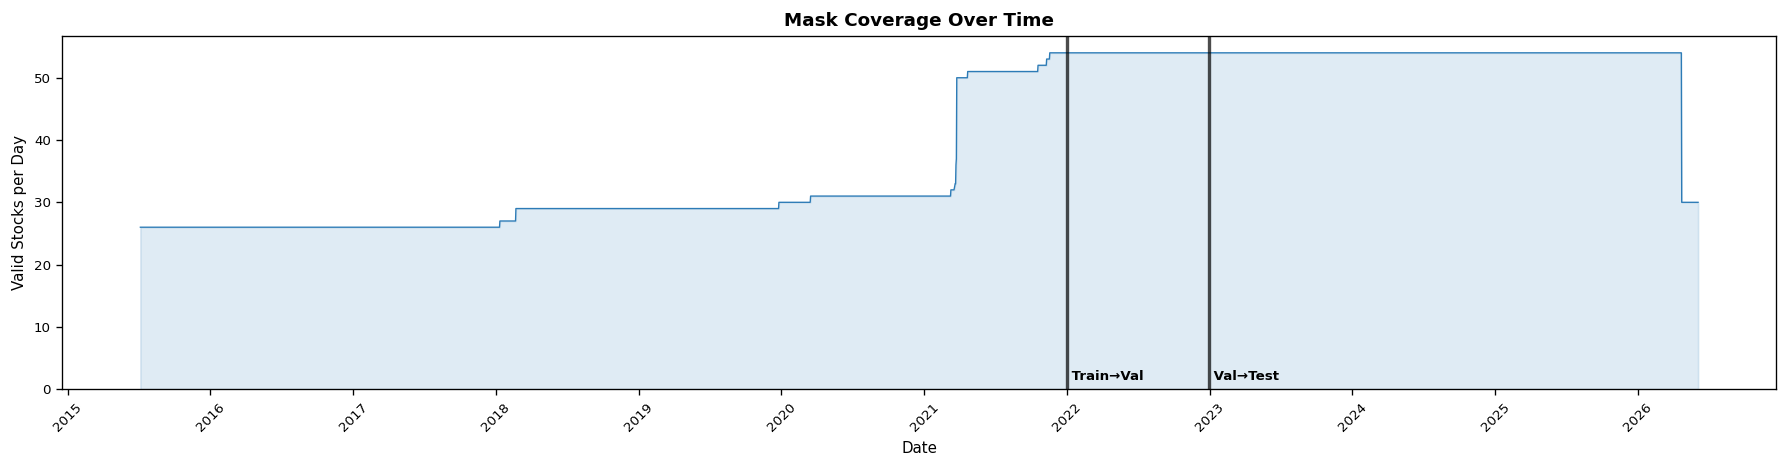

In [51]:
# ── 8e. Mask coverage over time ───────────────────────────────────────────────
daily_valid = mask_check.sum(dim=1).numpy()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(dates_pd, daily_valid, color=PALETTE["primary"], linewidth=0.8)
ax.fill_between(dates_pd, daily_valid, alpha=0.15, color=PALETTE["primary"])
for b, lbl in [(TRAIN_END_TS, "Train→Val"), (VAL_END_TS, "Val→Test")]:
    ax.axvline(b, color="black", linewidth=2, linestyle="-", alpha=0.7)
    ax.text(b, 1, f" {lbl}", fontsize=8, fontweight="bold", va="bottom")
ax.set_xlabel("Date")
ax.set_ylabel("Valid Stocks per Day")
ax.set_title("Mask Coverage Over Time")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diag_mask_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

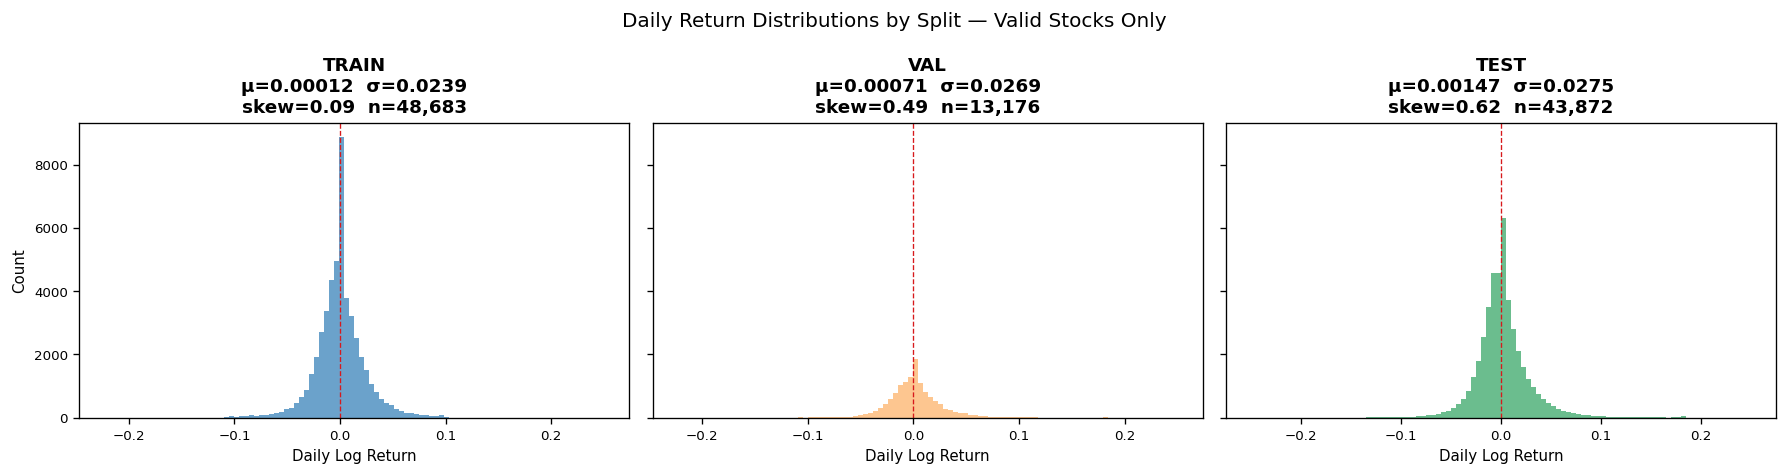

In [52]:
# ── 8f. Return distributions per split ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, split_name, color in zip(axes, ["train", "val", "test"],
                                  [PALETTE["train"], PALETTE["val"], PALETTE["test"]]):
    idx = splits_check[split_name]
    sr  = ret_check[idx[0]:idx[-1]+1]
    sm  = mask_check[idx[0]:idx[-1]+1]
    v   = sr[sm.bool()].numpy()
    ax.hist(v, bins=100, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(0, color=PALETTE["alert"], linewidth=0.8, linestyle="--")
    ax.set_title(f"{split_name.upper()}\n"
                 f"μ={v.mean():.5f}  σ={v.std():.4f}\n"
                 f"skew={float(pd.Series(v).skew()):.2f}  n={len(v):,}")
    ax.set_xlabel("Daily Log Return")
axes[0].set_ylabel("Count")
fig.suptitle("Daily Return Distributions by Split — Valid Stocks Only", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diag_return_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

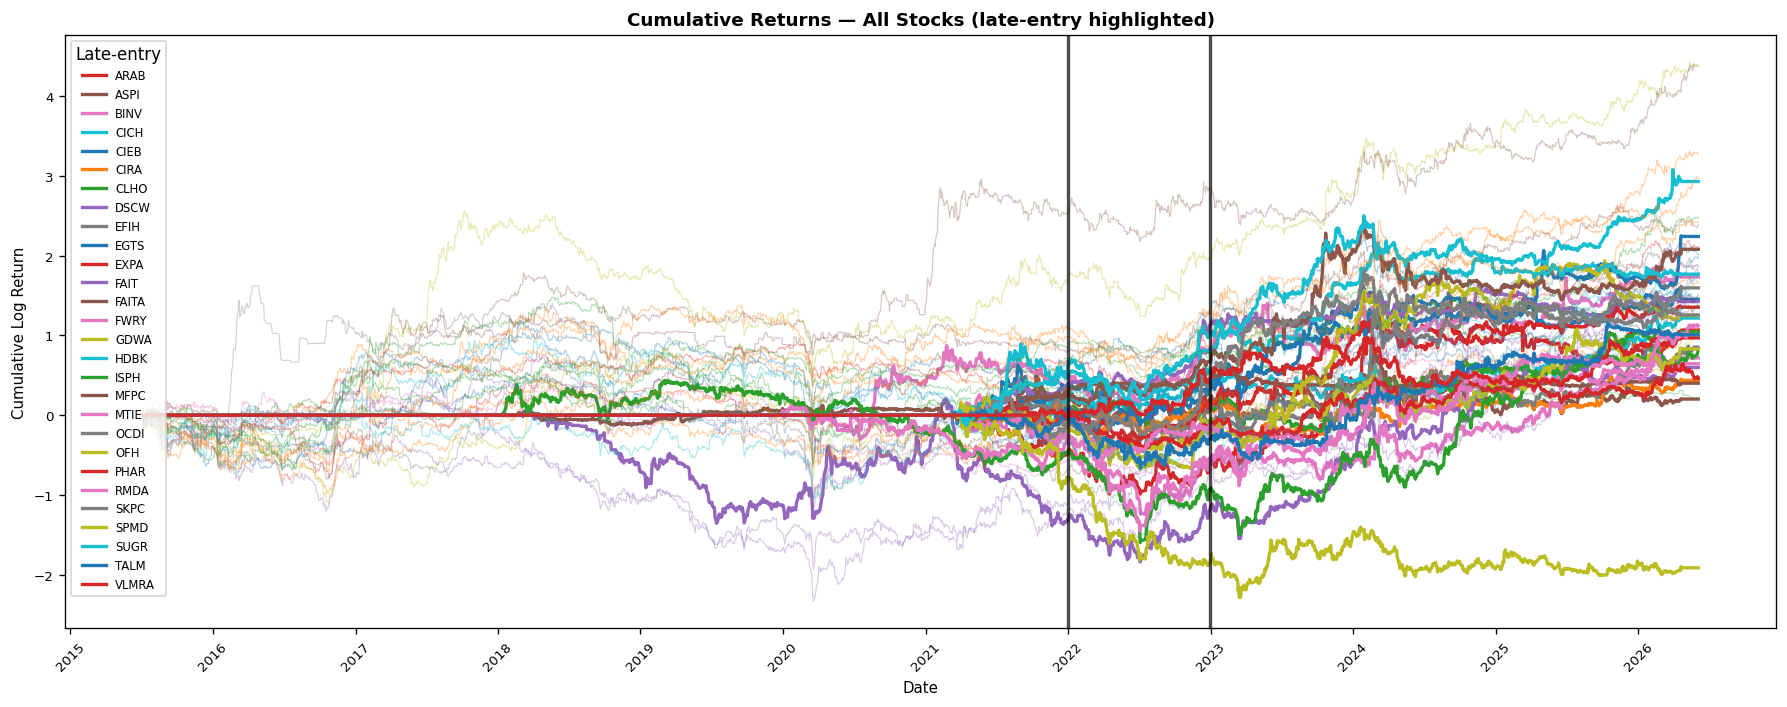

In [53]:
# ── 8g. Cumulative returns ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
for ticker in tickers:
    n_idx    = tickers.index(ticker)
    rets     = ret_check[:, n_idx].numpy()
    mask_col = mask_check[:, n_idx].numpy()
    cum      = np.cumsum(np.where(mask_col == 1, rets, 0))
    is_late  = ticker in late_tickers
    ax.plot(dates_pd, cum,
            alpha=1.0 if is_late else 0.35,
            linewidth=2.0 if is_late else 0.7,
            label=ticker if is_late else None)
for b, lbl in [(TRAIN_END_TS, "Train→Val"), (VAL_END_TS, "Val→Test")]:
    ax.axvline(b, color="black", linewidth=2, linestyle="-", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.set_title("Cumulative Returns — All Stocks (late-entry highlighted)")
ax.legend(loc="upper left", fontsize=7, title="Late-entry")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diag_cumulative_returns.png", dpi=120, bbox_inches="tight")
plt.show()

In [54]:
# ── 8h. Feature → forward return correlation ──────────────────────────────────
forward_5d = log_returns_trimmed[tickers].rolling(5).sum().shift(-5)

print("\n── Feature → 5-Day Forward Return Correlation (Training Only) ──")
print(f"{'Feature':<22} {'Avg Corr':>10} {'Signal'}")
print("─" * 50)
for i, name in enumerate(FEATURE_NAMES):
    panel = features[name].loc[train_dates]
    fwd   = forward_5d.loc[train_dates]
    corrs = []
    for ticker in full_history_tickers:
        valid = panel[ticker].notna() & fwd[ticker].notna()
        if valid.sum() < 100:
            continue
        corrs.append(panel[ticker][valid].corr(fwd[ticker][valid]))
    avg       = np.mean(corrs) if corrs else 0.0
    direction = "↑" if avg > 0.01 else ("↓" if avg < -0.01 else "—")
    strength  = ("notable"    if abs(avg) > 0.05 else
                 "mild"       if abs(avg) > 0.02 else
                 "weak"       if abs(avg) > 0.01 else "negligible")
    print(f"{name:<22} {avg:>+10.4f} {direction}  {strength}")

# Also check market signal vs forward return
signal_series = egx30_ma_ratio_trimmed.loc[train_dates]
fwd_mean_train = forward_5d.loc[train_dates].mean(axis=1)   # cross-sectional mean
valid_both = signal_series.notna() & fwd_mean_train.notna()
signal_fwd_corr = signal_series[valid_both].corr(fwd_mean_train[valid_both])
direction = "↑" if signal_fwd_corr > 0.01 else ("↓" if signal_fwd_corr < -0.01 else "—")
print(f"\n{'egx30_ma_ratio':<22} {signal_fwd_corr:>+10.4f} {direction}  "
      f"(vs cross-sectional mean forward return)")


── Feature → 5-Day Forward Return Correlation (Training Only) ──
Feature                  Avg Corr Signal
──────────────────────────────────────────────────
ret_1d                    +0.0953 ↑  notable
ret_5d                    +0.0144 ↑  weak
ret_20d                   +0.0229 ↑  mild
lgbm_pred                 +0.0099 —  negligible
gk_vol_20d                +0.0759 ↑  notable
skew_20d                  +0.0114 ↑  weak
kurt_20d                  -0.0065 —  negligible
rel_volume                +0.0011 —  negligible
avg_pairwise_corr         +0.0282 ↑  mild

egx30_ma_ratio            +0.0266 ↑  (vs cross-sectional mean forward return)


=============================================================================
9. Final Summary
=============================================================================

In [55]:
print("\n" + "=" * 70)
print("  NOTEBOOK 01 — FINAL SUMMARY")
print("=" * 70)
print(f"  Stocks           : {meta_check['n_stocks']} "
      f"({len(late_tickers)} late-entry, masked before entry)")
print(f"  Per-stock feats  : {meta_check['n_features']} — {meta_check['feature_names']}")
print(f"  Market signal    : egx30_ma_ratio (MA{MA_SHORT}/MA{MA_LONG}-1, lagged 1d)")
print(f"  Date range       : {meta_check['first_usable_date']} → {meta_check['date_end']}")
print(f"  Trading days     : {len(dindex_check)}")
print(f"  Train            : {meta_check['n_train_days']} days  (→ {meta_check['train_end']})")
print(f"  Validation       : {meta_check['n_val_days']} days  (→ {meta_check['val_end']})")
print(f"  Test             : {meta_check['n_test_days']} days  (→ {meta_check['date_end']})")
print(f"  Mask coverage    : {mask_check.mean()*100:.1f}% valid stock-days")
print(f"  Feature tensor   : {list(feat_check.shape)}")
print(f"  Returns tensor   : {list(ret_check.shape)}")
print(f"  Mask tensor      : {list(mask_check.shape)}")
print(f"  Market signal    : {list(signal_check.shape)}")
print(f"\n  Saved to:")
print(f"    Tensors  : {TENSORS_DIR.resolve()}")
print(f"    Metadata : {METADATA_DIR.resolve()}")
print(f"    Features : {FEATURES_DIR.resolve()}")
print(f"  Profile mask     : {list(profile_mask_check.shape)}  ({RISK_PROFILE})")
print("=" * 70)


  NOTEBOOK 01 — FINAL SUMMARY
  Stocks           : 54 (28 late-entry, masked before entry)
  Per-stock feats  : 9 — ['ret_1d', 'ret_5d', 'ret_20d', 'lgbm_pred', 'gk_vol_20d', 'skew_20d', 'kurt_20d', 'rel_volume', 'avg_pairwise_corr']
  Market signal    : egx30_ma_ratio (MA20/MA60-1, lagged 1d)
  Date range       : 2015-07-06 → 2026-06-04
  Trading days     : 2647
  Train            : 1579 days  (→ 2021-12-31)
  Validation       : 244 days  (→ 2022-12-31)
  Test             : 824 days  (→ 2026-06-04)
  Mask coverage    : 74.0% valid stock-days
  Feature tensor   : [2647, 54, 9]
  Returns tensor   : [2647, 54]
  Mask tensor      : [2647, 54]
  Market signal    : [2647, 2]

  Saved to:
    Tensors  : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\tensors
    Metadata : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\metadata
    Features : C:\Users\youssef\Desktop\Portfolio_Personalization\data\processed\features
  Profile mask     : [2647, 54]  (cons